## Vision fine tuning

In [12]:
from fastai.vision.all import *

In [21]:
path = untar_data(URLs.PETS)
print('path=',path)
path.ls()

path= /Users/Yashwanth.B/.fastai/data/oxford-iiit-pet


[Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/.DS_Store'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/models'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/annotations')]

In [24]:
files = get_image_files(path/'images')
files[0]

Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_167.jpg')

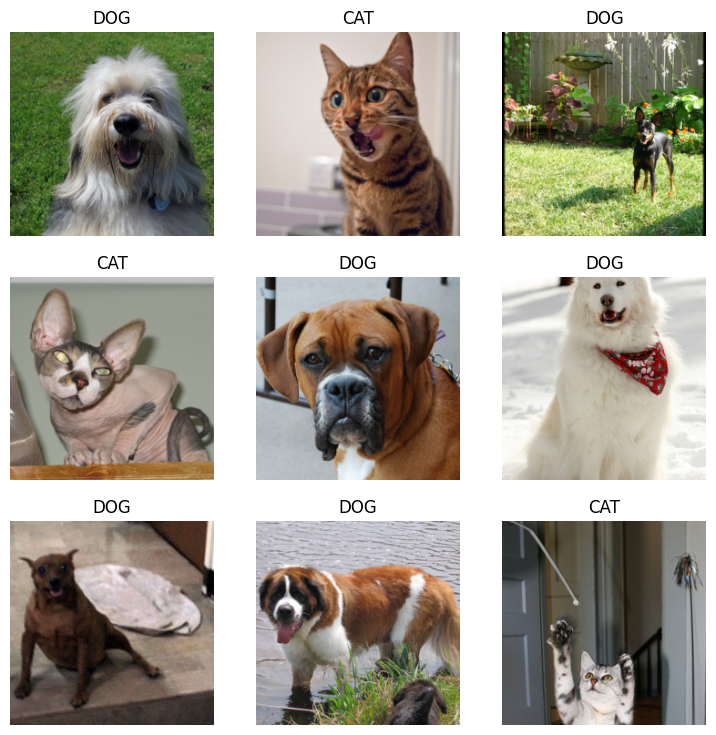

In [69]:
def label_func(f): 
    output = 'CAT' if f[0].isupper() else 'DOG'
    return output
dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(224))
dls.show_batch()

In [70]:
learner = vision_learner(dls, resnet18, metrics=[accuracy, error_rate])

<div></div>

SuggestedLRs(valley=0.0008317637839354575)


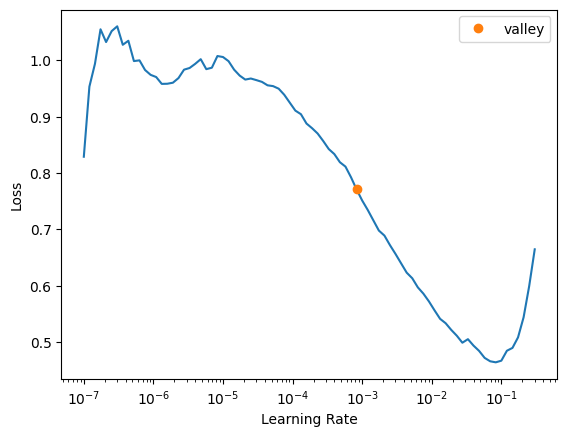

In [71]:
lrs = learner.lr_find(suggest_funcs=(valley))
print(lrs)

In [72]:
learner.fine_tune(1, lrs.valley)

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.215600,0.033925,0.988498,0.011502,00:42


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.057605,0.017076,0.994587,0.005413,00:56


In [76]:
learner.predict("Cat-test.jpeg")

('CAT', tensor(0), tensor([1.0000e+00, 2.6272e-10]))

## Tabular finetuning

In [2]:
from fastai.tabular.all import *

In [6]:
path = untar_data(URLs.ADULT_SAMPLE)
path.ls()

<div><progress max="968212" value="974848"></progress> 100.69% [974848/968212 00:01&lt;00:00]</div>

[Path('/Users/Yashwanth.B/.fastai/data/adult_sample/adult.csv'), Path('/Users/Yashwanth.B/.fastai/data/adult_sample/export.pkl'), Path('/Users/Yashwanth.B/.fastai/data/adult_sample/models')]

In [18]:
dls = TabularDataLoaders.from_csv(
    path/"adult.csv",
    path=path,
    y_names='salary',
    cat_names=['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race'],
    cont_names=['fnlwgt', 'education-num','age'],
    procs=[Categorify, FillMissing, Normalize]
)
dls.show_batch()

/Users/Yashwanth.B/jupyter/jenv/lib/python3.10/site-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to[n].fillna(self.na_dict[n], inplace=True)


,workclass,education,marital-status,occupation,relationship,race,education-num_na,fnlwgt,education-num,age,salary
0,Private,Some-college,Never-married,Protective-serv,Not-in-family,White,False,137875.999190,10.0,22.000000,<50k
1,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,False,112753.998676,13.0,27.000000,>=50k
2,Federal-gov,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,False,237819.000020,13.0,51.000000,>=50k
3,Private,Some-college,Never-married,Handlers-cleaners,Other-relative,Black,False,227488.999425,10.0,26.000000,<50k
4,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,False,126944.999634,13.0,22.999999,<50k
5,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,False,403518.994113,9.0,22.000000,<50k
6,Private,Assoc-voc,Married-spouse-absent,Prof-specialty,Unmarried,White,False,200426.000131,11.0,35.000000,<50k
7,Private,HS-grad,Divorced,Handlers-cleaners,Own-child,White,False,182073.999785,9.0,35.000000,<50k
8,Private,9th,Never-married,Transport-moving,Own-child,White,False,129979.999812,5.0,21.000001,<50k
9,Private,Bachelors,Never-married,Prof-specialty,Own-child,White,False,189620.000002,13.0,30.000000,<50k


In [47]:
learner = tabular_learner(dls, metrics=[error_rate, accuracy])
learner.fit_one_cycle(20, cbs=SaveModelCallback(monitor='valid_loss', fname='bestmodel'))

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.508386,0.503038,0.222973,0.777027,00:02
1,0.397094,0.394432,0.176904,0.823096,00:02
2,0.359222,0.364096,0.164926,0.835074,00:02
3,0.362298,0.365284,0.166462,0.833538,00:02
4,0.364284,0.356511,0.167383,0.832617,00:02
5,0.359919,0.356129,0.166462,0.833538,00:02
6,0.350478,0.367635,0.167076,0.832924,00:02
7,0.354982,0.364278,0.171990,0.828010,00:02
8,0.355521,0.352354,0.160012,0.839988,00:02
9,0.344916,0.355508,0.160012,0.839988,00:02


Better model found at epoch 0 with valid_loss value: 0.5030378699302673.
Better model found at epoch 1 with valid_loss value: 0.39443185925483704.
Better model found at epoch 2 with valid_loss value: 0.36409592628479004.
Better model found at epoch 4 with valid_loss value: 0.3565107583999634.
Better model found at epoch 5 with valid_loss value: 0.3561292588710785.
Better model found at epoch 8 with valid_loss value: 0.3523535430431366.
Better model found at epoch 11 with valid_loss value: 0.35097572207450867.
Better model found at epoch 14 with valid_loss value: 0.35093602538108826.
Better model found at epoch 18 with valid_loss value: 0.3502417802810669.
Better model found at epoch 19 with valid_loss value: 0.3500882089138031.


In [62]:
learner.load('bestmodel')
learner.validate()

[0.3500882089138031, 0.15924447774887085, 0.8407555222511292]

In [53]:
learner.show_results()
learner.summary()

,workclass,education,marital-status,occupation,relationship,race,education-num_na,fnlwgt,education-num,age,salary,salary_pred
0,5.0,13.0,5.0,5.0,4.0,5.0,1.0,1.390777,1.540118,-0.849293,0.0,0.0
1,5.0,12.0,3.0,8.0,1.0,5.0,1.0,-0.526931,-0.421438,-0.849293,0.0,0.0
2,5.0,16.0,5.0,4.0,2.0,5.0,1.0,-1.005926,-0.029127,-0.115470,0.0,0.0
3,5.0,16.0,3.0,4.0,1.0,5.0,1.0,0.087707,-0.029127,-0.482381,0.0,0.0
4,5.0,12.0,7.0,0.0,2.0,5.0,1.0,1.528715,-0.421438,1.572323,0.0,0.0
5,5.0,16.0,5.0,10.0,2.0,5.0,1.0,-0.008450,-0.029127,-1.436351,0.0,0.0
6,5.0,16.0,3.0,11.0,1.0,5.0,1.0,1.467183,-0.029127,0.985265,0.0,1.0
7,5.0,16.0,5.0,9.0,4.0,5.0,1.0,0.150192,-0.029127,-1.509733,0.0,0.0
8,7.0,8.0,3.0,5.0,1.0,5.0,1.0,-0.860099,0.755495,0.911883,1.0,0.0


<div></div>

TabularModel (Input shape: 64 x 7)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 6              
Embedding                                 60         True      
____________________________________________________________________________
                     64 x 8              
Embedding                                 136        True      
____________________________________________________________________________
                     64 x 5              
Embedding                                 40         True      
____________________________________________________________________________
                     64 x 8              
Embedding                                 128        True      
____________________________________________________________________________
                     64 x 5              
Embedding                                 35         True      
_______________________________________________________________

In [39]:
import pandas as pd
row = {
    'workclass': 'Private',
    'education': 'Assoc-acdm',
    'marital-status': 'Married-civ-spouse',
    'occupation': 'Sales',
    'relationship': 'Wife',
    'race': 'White',
    'fnlwgt': 101320,
    'education-num': 12,
    'age': 49
}
row_frame=pd.DataFrame([row])
learner.predict(row_frame.iloc[0])

/Users/Yashwanth.B/jupyter/jenv/lib/python3.10/site-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to[n].fillna(self.na_dict[n], inplace=True)


(   workclass  education  marital-status  occupation  relationship  race  \
 0        5.0        8.0             3.0        13.0           6.0   5.0   
 
    education-num_na    fnlwgt  education-num       age  salary  
 0               1.0 -0.839757       0.755495  0.765118     1.0  ,
 tensor(1),
 tensor([0.2916, 0.7084]))

In [40]:
learner.dls.vocab

['<50k', '>=50k']

<div></div>

SuggestedLRs(valley=0.0020892962347716093)

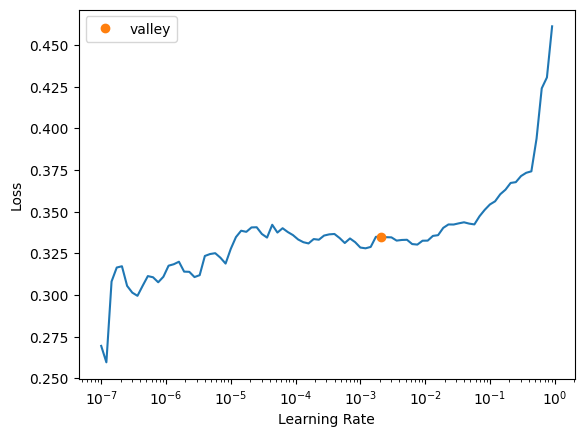

In [54]:
learner.lr_find()

In [55]:
learner.path.ls()
(learner.path/'models').ls()

[Path('/Users/Yashwanth.B/.fastai/data/adult_sample/models/bestmodel.pth'), Path('/Users/Yashwanth.B/.fastai/data/adult_sample/models/mini_train.pth'), Path('/Users/Yashwanth.B/.fastai/data/adult_sample/models/model.pth')]

In [58]:
learner.validate()

[0.3500882089138031, 0.15924447774887085, 0.8407555222511292]

In [61]:
learner.metrics

[<fastai.learner.AvgMetric object at 0x11ffb9990>, <fastai.learner.AvgMetric object at 0x11ffb9f60>]

## Vision training

In [1]:
from fastai.vision.all import *

AttributeError: type object 'URLs' has no attribute 'CAT'